importando as bibliotecas:

In [30]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib as plt

Para exibir os valores sem notacao cientifica:

In [14]:
pd.options.display.float_format="{:.2f}".format

trazendo o dataset do projeto

In [6]:
vendas = pd.read_csv('vendas_supermercado_com_cliente.csv',parse_dates=['Data'])

observando as primeiras linhas para entender o dataset

In [7]:
vendas.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42


verificando os formatos das colunas e se há valores nulos

In [8]:
vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data         20075 non-null  datetime64[us]
 1   Produto      20075 non-null  str           
 2   Categoria    20075 non-null  str           
 3   Preço        20075 non-null  float64       
 4   Quantidade   20075 non-null  int64         
 5   Desconto     20075 non-null  float64       
 6   Total_Venda  20075 non-null  float64       
 7   Idade        20075 non-null  int64         
 8   Renda        20075 non-null  float64       
dtypes: datetime64[us](1), float64(4), int64(2), str(2)
memory usage: 1.4 MB


In [16]:
vendas.describe()

,Data,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
count,20075,20075.00,20075.00,20075.00,20075.00,20075.00,20075.00
mean,2023-07-02 00:00:00,25.58,10.01,0.04,245.90,45.99,2999.03
min,2023-01-01 00:00:00,1.00,1.00,0.00,0.91,18.00,1000.38
25%,2023-04-02 00:00:00,13.26,5.00,0.00,75.60,32.00,1993.62
50%,2023-07-02 00:00:00,25.66,10.00,0.00,186.32,46.00,2998.83
75%,2023-10-01 00:00:00,37.77,15.00,0.00,370.04,60.00,4007.68
max,2023-12-31 00:00:00,49.99,19.00,0.50,949.05,74.00,4999.76
std,NaN,14.12,5.49,0.09,207.77,16.48,1159.72


analisando as primeiras estatisticas, vemos que o dataset tem dados compreendidos de 01/01/2023 até 31/12/2023 e não parecem ter dados muito fora do padrão, como descontos muito altos, valores unitarios muito grande

agrupando o total de vendas por categoria

In [15]:
vendas.groupby('Categoria')['Total_Venda'].sum()

Categoria
Alimentos Frescos             1365309.46
Bebidas                        454394.16
Congelados                     439720.13
Laticínios e Ovos              459960.47
Pet Shop                       440331.56
Produtos de Higiene Pessoal    440039.48
Produtos de Limpeza            447545.86
Produtos de Mercearia          529653.65
Utilidades Domésticas          359522.58
Name: Total_Venda, dtype: float64

In [17]:
vendas.groupby('Categoria')['Total_Venda'].mean()

Categoria
Alimentos Frescos             249.37
Bebidas                       248.98
Congelados                    240.94
Laticínios e Ovos             252.03
Pet Shop                      241.28
Produtos de Higiene Pessoal   241.12
Produtos de Limpeza           245.23
Produtos de Mercearia         241.85
Utilidades Domésticas         246.25
Name: Total_Venda, dtype: float64

In [23]:
vendas['mes'] = vendas['Data'].dt.month_name(locale='pt_BR.utf-8')

In [24]:
vendas.head()

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,mes
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.00,164.60,49,2715.61,Janeiro
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.00,9.56,29,2280.15,Janeiro
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.00,41.90,67,4419.56,Janeiro
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.00,30.45,29,3809.17,Janeiro
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.00,519.96,24,1013.42,Janeiro


In [26]:
vendas_categoria_mes = vendas.groupby(['Categoria','mes'])['Total_Venda'].sum()

In [27]:
vendas_categoria_mes['Alimentos Frescos']

mes
Abril        98847.67
Agosto      114280.75
Dezembro    111652.58
Fevereiro   109234.29
Janeiro     116281.50
Julho       126769.38
Junho       120631.54
Maio        103923.98
Março       129103.45
Novembro    105294.10
Outubro     116440.75
Setembro    112849.47
Name: Total_Venda, dtype: float64

In [28]:
vendas_categoria_mes['Bebidas']

mes
Abril       34483.97
Agosto      36042.42
Dezembro    30446.98
Fevereiro   37873.91
Janeiro     47415.71
Julho       45443.17
Junho       38275.18
Maio        38709.04
Março       37484.52
Novembro    36574.03
Outubro     39739.86
Setembro    31905.38
Name: Total_Venda, dtype: float64

<Axes: xlabel='Categoria,mes'>

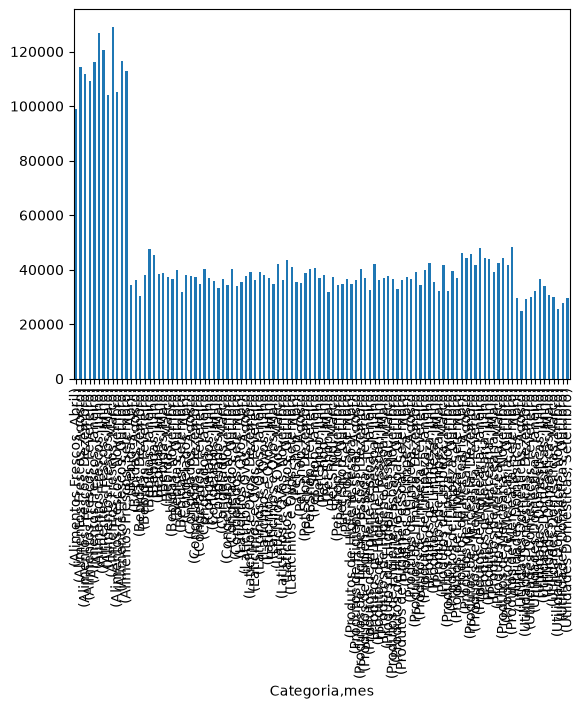

In [31]:
vendas_categoria_mes.plot(kind='bar')